```text

Business Understanding
        ↓
Data Collection (text corpus / scraping / API / dataset)
        ↓
Dataset Understanding (classes, text length, language, imbalance)
        ↓
Text Cleaning
   - Lowercasing
   - Remove punctuation, special chars, URLs, HTML tags
   - Remove/handle emojis
   - Remove stopwords (task-dependent)
   - Spelling correction (if needed)
        ↓
Handle Missing / Duplicate / Noisy Text
        ↓
Tokenization
   - Word-level / Subword (BPE, WordPiece) / Sentence-level
        ↓
Text Normalization
   - Stemming / Lemmatization
        ↓
Exploratory Data Analysis (EDA)
   - Word frequency, word clouds
   - Text length distribution
   - Class distribution
   - N-gram analysis
        ↓
Feature Engineering (if classical ML)
   - Bag of Words / TF-IDF / N-grams
   - POS tags, NER features (if relevant)
        ↓
Encoding
   - Label Encoding (target)
   - Text Vectorization:
     → Classical: BoW / TF-IDF
     → Deep Learning: Embedding layer / Word2Vec / GloVe / FastText
     → Transformers: Tokenizer (BPE/WordPiece) + attention masks
        ↓
Define Features (X) and Target (y)
        ↓
Train-Validation-Test Split
        ↓
Padding / Truncation (for sequence models)
        ↓
Convert to Tensors
        ↓
Create Dataset & DataLoader
        ↓
Design Model Architecture
   - Classical: Naive Bayes / Logistic Regression / SVM
   - Deep Learning: RNN / LSTM / GRU / CNN-text
   - Transformer: Pretrained (BERT/DistilBERT/RoBERTa) + fine-tune head
        ↓
Choose Loss Function (CrossEntropy / BCE etc.)
        ↓
Choose Optimizer (Adam / AdamW + scheduler for transformers)
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning
        ↓
Model Evaluation
   - Accuracy, Precision, Recall, F1
   - Confusion Matrix
   - (Task-specific: BLEU/ROUGE for generation, perplexity for LM)
        ↓
Error Analysis (misclassified examples — NLP-specific step)
        ↓
Save Trained Model + Tokenizer/Vectorizer
        ↓
Inference / Prediction
        ↓
Deployment
        ↓
GitHub + README

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv(r"C:\Users\rohit\Downloads\AI and Data Science\𝗡𝗟𝗣 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Spam email classifier\data\combined_data.csv")

df

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


In [3]:
#dataset understanding

df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [4]:
df.sample()

,label,text
73298,1,"receive\nunlimited visitors , it cost you not ..."


In [5]:
df.shape

(83448, 2)

In [6]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print(df['label'].value_counts())
# Calculate class percentages
print("\nClass Distribution (%):")
print((df['label'].value_counts(normalize=True) * 100).round(2))

label
1    43910
0    39538
Name: count, dtype: int64

Class Distribution (%):
label
1    52.62
0    47.38
Name: proportion, dtype: float64


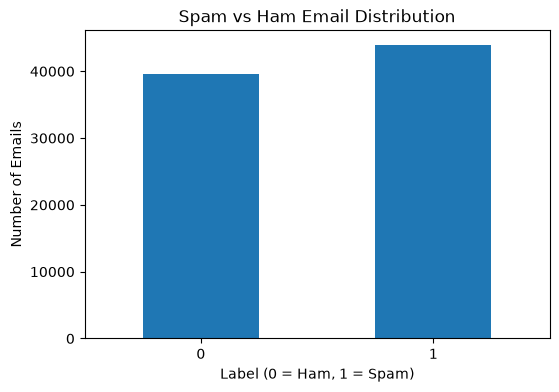

In [9]:
import matplotlib.pyplot as plt

df['label'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

In [10]:
# # Text Cleaning
#    - Lowercasing
#    - Remove punctuation, special chars, URLs, HTML tags
#    - Remove/handle emojis
#    - Remove stopwords (task-dependent)
#    - Spelling correction (if needed)

In [11]:
#lowercasing

df.sample()

,label,text
78821,0,hello everybody how can i filter a dataset im ...


In [12]:
df['text'] = df['text'].str.lower()

In [13]:
df.sample(2)

,label,text
13863,1,stop getting spam free oneclick spam stopper c...
37151,0,hi i upgraded my system from fcescapenumber to...


In [14]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\rohit\AppData\Local\Python\pythoncore-3.12-64\python.exe -m pip install --upgrade pip


In [15]:
#    - Remove punctuation, special chars, URLs, HTML tags

#using beautifulsoap library to remove html tags

from bs4 import BeautifulSoup

df['text'] = df['text'].apply(lambda x: BeautifulSoup(x, 'html.parser').get_text())

#done


In [16]:
#using regex for urls removal

import re

df['text'] = df['text'].apply(lambda x: re.sub(r'https?://\S+|www\.\S+', '', x))

In [19]:
#punctuation

import string

df['text'] = df['text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

In [20]:
#removing stopwords now using nltk 

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [21]:
#apply to our dataset

df['text'] = df['text'].apply(remove_stopwords)

In [24]:
# import spacy

# nlp = spacy.blank("en")

# def tokenize(text):
#     doc = nlp(text)
#     return [token.text for token in doc]

# df['text'] = df['text'].apply(tokenize)

# #accidently run the cell twice thats why it is producing an error because now everything is already tokenized 

In [26]:
df

,label,text
0,1,"[ounce, feather, bowl, hummingbird, opec, mome..."
1,1,"[wulvob, get, medircations, online, qnb, ikud,..."
2,0,"[computer, connection, cnn, com, wednesday, es..."
3,1,"[university, degree, obtain, prosperous, futur..."
4,0,"[thanks, answers, guys, know, checked, rsync, ..."
...,...,...
83443,0,"[hi, given, date, get, last, date, month, data..."
83444,1,"[order, software, cd, download, site, immediat..."
83445,1,"[dear, valued, member, canadianpharmacy, provi..."
83446,0,"[subscribe, change, profile, contact, us, long..."


In [27]:
#text normalization

#skipping leminization and stemming for now it took a lot of time to execute their block